In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
np.random.seed(42)

print("NumPy, Pandas, Matplotlib and Seaborn loaded successfully.")

NumPy, Pandas, Matplotlib and Seaborn loaded successfully.


In [2]:
# Create a realistic transaction dataset using NumPy and Pandas
n = 10000
rng = np.random.default_rng(42)

df = pd.DataFrame({
    "Transaction_ID": np.arange(1, n + 1),
    "Amount": np.round(rng.gamma(2.2, 75, n), 2),
    "Transaction_Time": rng.integers(0, 24 * 60, n),
    "Transaction_Type": rng.choice(
        ["Online", "POS", "ATM", "Mobile"],
        n,
        p=[0.35, 0.35, 0.15, 0.15]
    ),
    "Location": rng.choice(
        ["Lucknow", "Delhi", "Mumbai", "Bengaluru", "Kolkata", "Other"],
        n
    ),
    "Customer_Age": rng.integers(18, 75, n),
    "Failed_Attempts": rng.poisson(0.35, n),
    "Fraud": rng.choice([0, 1], n, p=[0.985, 0.015])
})

# Add missing values for cleaning demonstration
for col in ["Amount", "Customer_Age", "Transaction_Type"]:
    idx = rng.choice(df.index, 40, replace=False)
    df.loc[idx, col] = np.nan

# Add extreme values for outlier detection
outlier_idx = rng.choice(df.index, 15, replace=False)
df.loc[outlier_idx, "Amount"] = df["Amount"].median() * 15

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (10000, 8)


,Transaction_ID,Amount,Transaction_Time,Transaction_Type,Location,Customer_Age,Failed_Attempts,Fraud
0,1,173.60,1364,Online,Other,60.0,0,0
1,2,231.84,851,Online,Bengaluru,64.0,1,0
2,3,153.51,266,Online,Lucknow,60.0,1,0
3,4,138.29,836,Online,Kolkata,72.0,0,0
4,5,250.83,887,ATM,Other,59.0,0,0


In [4]:
# Understand the dataset structure , coliumns, dta types and statistical summary.
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Rows: 10000
Columns: 8

Column Names:
['Transaction_ID', 'Amount', 'Transaction_Time', 'Transaction_Type', 'Location', 'Customer_Age', 'Failed_Attempts', 'Fraud']

Data Types:
Transaction_ID        int64
Amount              float64
Transaction_Time      int64
Transaction_Type     object
Location             object
Customer_Age        float64
Failed_Attempts       int64
Fraud                 int64
dtype: object

Duplicate Rows: 0

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Amount,9960.0,NaN,NaN,NaN,169.189068,135.7721,2.13,84.045,141.63,221.2825,2120.25
Transaction_Time,10000.0,NaN,NaN,NaN,717.6074,415.146724,0.0,357.0,717.0,1079.0,1439.0
Transaction_Type,9960,4,POS,3509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,10000,6,Other,1696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,9960.0,NaN,NaN,NaN,46.12249,16.47577,18.0,32.0,46.0,60.0,74.0
Failed_Attempts,10000.0,NaN,NaN,NaN,0.3496,0.594319,0.0,0.0,0.0,1.0,4.0
Fraud,10000.0,NaN,NaN,NaN,0.0165,0.127395,0.0,0.0,0.0,0.0,1.0


In [5]:
# Misssing value before cleaning the dataset
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

display(missing_report[missing_report["Missing Count"] > 0])

,Missing Count,Missing Percentage
Amount,40,0.4
Transaction_Type,40,0.4
Customer_Age,40,0.4


In [6]:
# Handling Missing Value
# Numerical missing values
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Categorical missing values
for col in df.select_dtypes(include="object").columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Total missing values after cleaning:", df.isnull().sum().sum())

Total missing values after cleaning: 0


In [7]:
# Duplicate data cleaning
duplicate_count = df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows found: 0
Duplicate rows after cleaning: 0


In [8]:
# Outlier detection Transaction Amount
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["Amount"] < lower_limit) | (df["Amount"] > upper_limit)]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Limit:", round(lower_limit, 2))
print("Upper Limit:", round(upper_limit, 2))
print("Number of outliers:", len(outliers))

Q1: 84.28
Q3: 220.82
IQR: 136.54
Lower Limit: -120.52
Upper Limit: 425.64
Number of outliers: 352


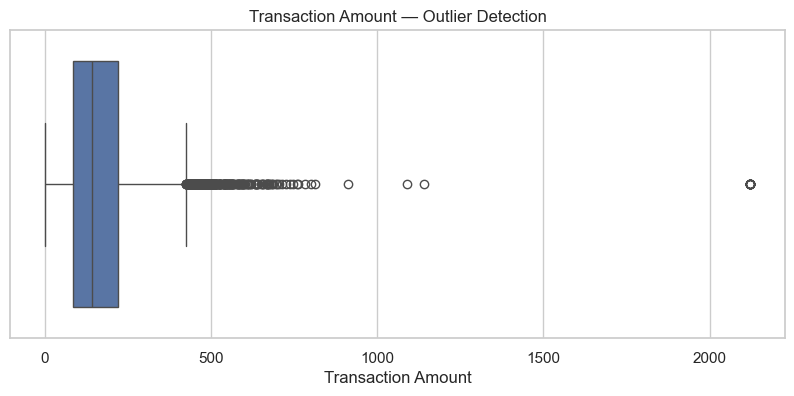

In [9]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Amount"])
plt.title("Transaction Amount — Outlier Detection")
plt.xlabel("Transaction Amount")
plt.show()

In [10]:
# Outlier Handling
df["Amount_Cleaned"] = df["Amount"].clip(lower=lower_limit, upper=upper_limit)

print("Maximum amount before:", round(df["Amount"].max(), 2))
print("Maximum amount after:", round(df["Amount_Cleaned"].max(), 2))

Maximum amount before: 2120.25
Maximum amount after: 425.63


In [11]:
# Fraud Distribution 
fraud_summary = df["Fraud"].value_counts().sort_index()

summary = pd.DataFrame({
    "Status": ["Legitimate", "Fraud"],
    "Transactions": [
        fraud_summary.get(0, 0),
        fraud_summary.get(1, 0)
    ]
})

summary["Percentage"] = (
    summary["Transactions"] / len(df) * 100
).round(2)

display(summary)

,Status,Transactions,Percentage
0,Legitimate,9835,98.35
1,Fraud,165,1.65


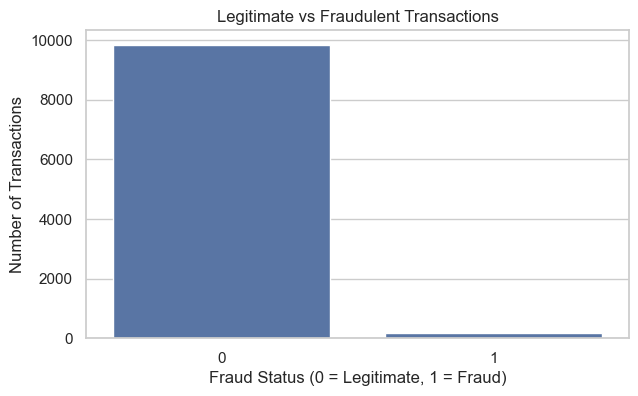

In [12]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Fraud")
plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

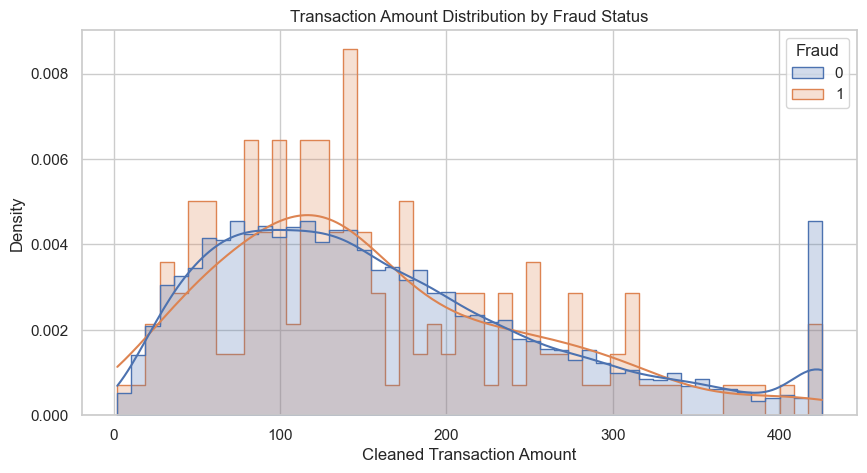

In [13]:
# Transaction Amount Distribution
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Amount_Cleaned",
    hue="Fraud",
    bins=50,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Cleaned Transaction Amount")
plt.ylabel("Density")
plt.show()

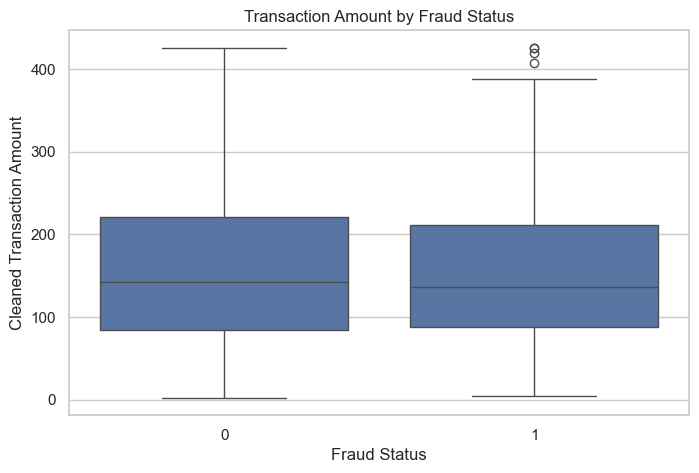

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Fraud", y="Amount_Cleaned")
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Cleaned Transaction Amount")
plt.show()

,Legitimate (%),Fraud (%)
Transaction_Type,,
ATM,98.88,1.12
Mobile,98.58,1.42
Online,98.38,1.62
POS,98.00,2.00


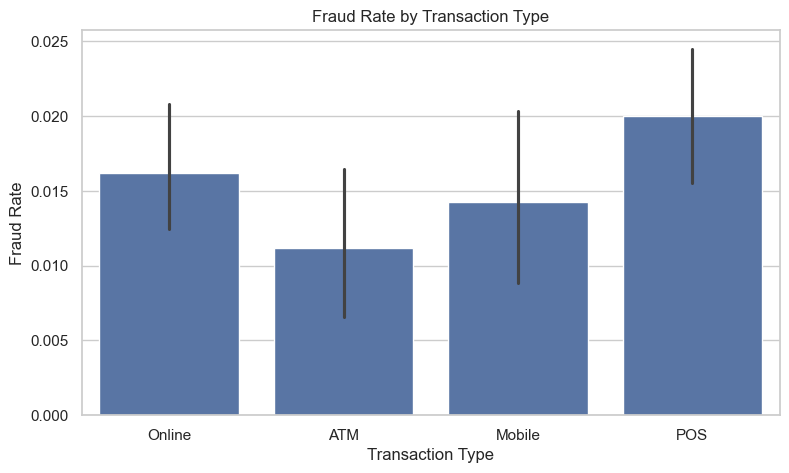

In [15]:
# Fraud Analysis by Transaction type 
type_fraud = pd.crosstab(
    df["Transaction_Type"],
    df["Fraud"],
    normalize="index"
) * 100

type_fraud.columns = ["Legitimate (%)", "Fraud (%)"]

display(type_fraud.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Transaction_Type",
    y="Fraud",
    estimator=np.mean
)
plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

,Legitimate (%),Fraud (%)
Location,,
Lucknow,97.67,2.33
Kolkata,97.72,2.28
Mumbai,98.32,1.68
Other,98.64,1.36
Delhi,98.81,1.19
Bengaluru,98.94,1.06


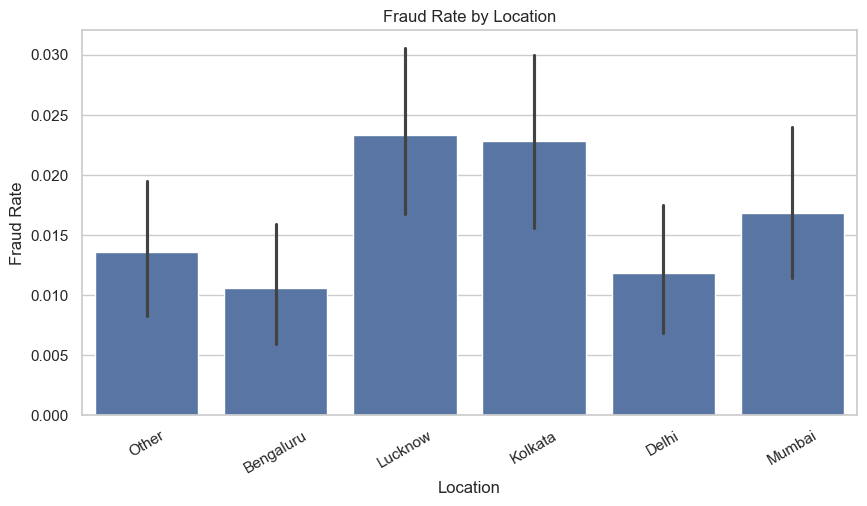

In [16]:
# Fraud Analysis by Location
location_fraud = pd.crosstab(
    df["Location"],
    df["Fraud"],
    normalize="index"
) * 100

location_fraud.columns = ["Legitimate (%)", "Fraud (%)"]

display(location_fraud.sort_values("Fraud (%)", ascending=False).round(2))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x="Location",
    y="Fraud",
    estimator=np.mean
)
plt.title("Fraud Rate by Location")
plt.xlabel("Location")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=30)
plt.show()

,Transactions,Fraud_Rate
Failed_Attempts,,
0,7056,1.69
1,2467,1.74
2,404,0.00
3,71,4.23
4,2,0.00


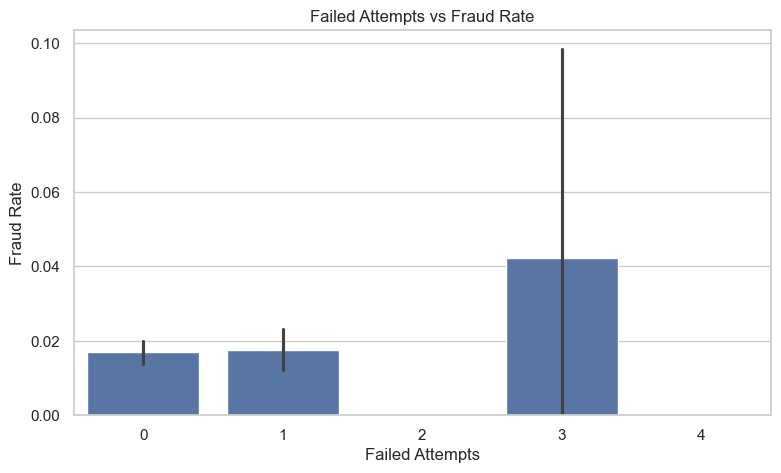

In [17]:
# Failed Attempts Analysis 
attempt_analysis = df.groupby("Failed_Attempts")["Fraud"].agg(
    Transactions="count",
    Fraud_Rate="mean"
)

attempt_analysis["Fraud_Rate"] = (
    attempt_analysis["Fraud_Rate"] * 100
).round(2)

display(attempt_analysis.head(10))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Failed_Attempts",
    y="Fraud"
)
plt.title("Failed Attempts vs Fraud Rate")
plt.xlabel("Failed Attempts")
plt.ylabel("Fraud Rate")
plt.show()

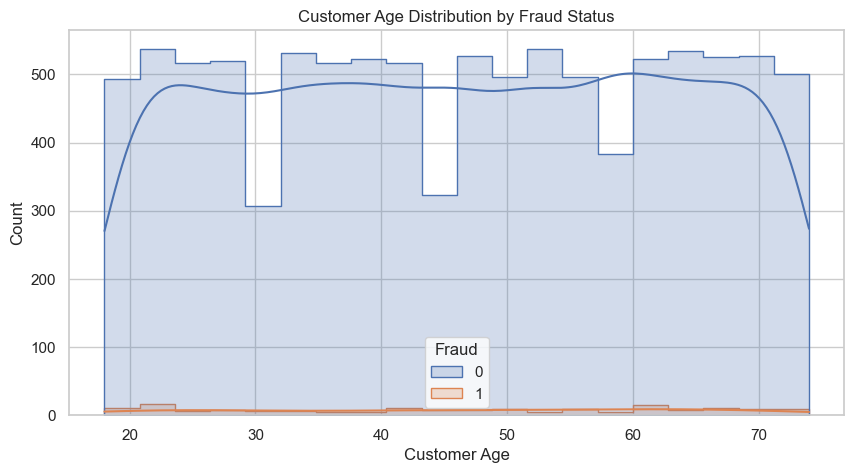

In [19]:
# Customer Age Analysis 
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Customer_Age",
    hue="Fraud",
    bins=20,
    kde=True,
    element="step",
    common_norm=False
)
plt.title("Customer Age Distribution by Fraud Status")
plt.xlabel("Customer Age")
plt.ylabel("Count")
plt.show()

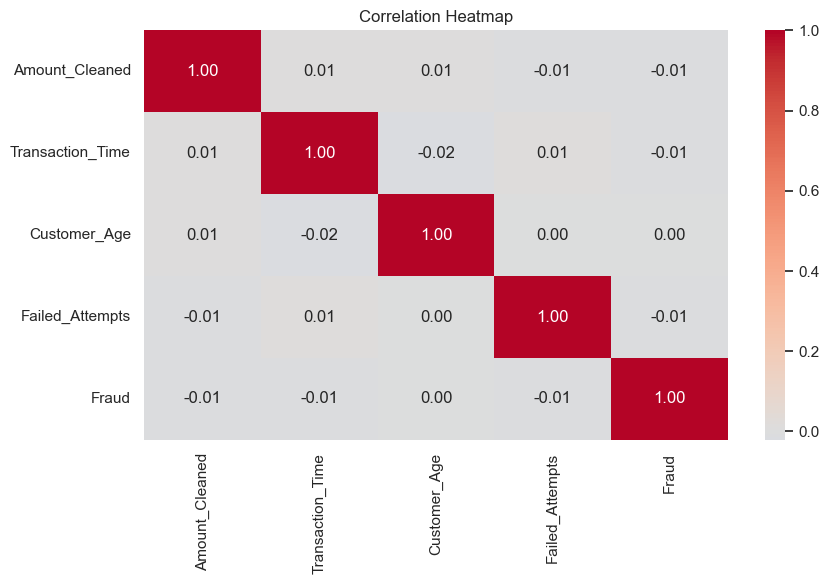

In [20]:
# Correlation Analysis .
corr_cols = [
    "Amount_Cleaned",
    "Transaction_Time",
    "Customer_Age",
    "Failed_Attempts",
    "Fraud"
]

correlation = df[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [21]:
# Final Clean Dataset 
print("Final Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

display(df.head(10))

# Save cleaned transaction data
df.to_csv("cleaned_fraud_transactions.csv", index=False)

print("\nCleaned dataset exported successfully.")

Final Dataset Shape: (10000, 9)
Missing Values: 0
Duplicate Rows: 0


,Transaction_ID,Amount,Transaction_Time,Transaction_Type,Location,Customer_Age,Failed_Attempts,Fraud,Amount_Cleaned
0,1,173.60,1364,Online,Other,60.0,0,0,173.60
1,2,231.84,851,Online,Bengaluru,64.0,1,0,231.84
2,3,153.51,266,Online,Lucknow,60.0,1,0,153.51
3,4,138.29,836,Online,Kolkata,72.0,0,0,138.29
4,5,250.83,887,ATM,Other,59.0,0,0,250.83
5,6,146.88,940,Online,Other,24.0,0,0,146.88
6,7,193.58,462,Online,Other,60.0,0,0,193.58
7,8,181.29,1354,Mobile,Other,31.0,0,0,181.29
8,9,250.68,341,POS,Kolkata,62.0,0,0,250.68
9,10,121.90,708,Online,Other,54.0,0,0,121.90



Cleaned dataset exported successfully.
